## **1. SETUP AND DATA LOADING (TITANIC DATASET)**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

df = pd.read_csv(r'C:\Users\Student\Downloads\titanic.csv')
print(f"The Shape is: {df.shape}")
df.head(10)

The Shape is: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


 ## **2. Initial Inspection**

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [34]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


#### Count and Percentages of missing values

In [35]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


### Graph Plot of Missing_Values by Column

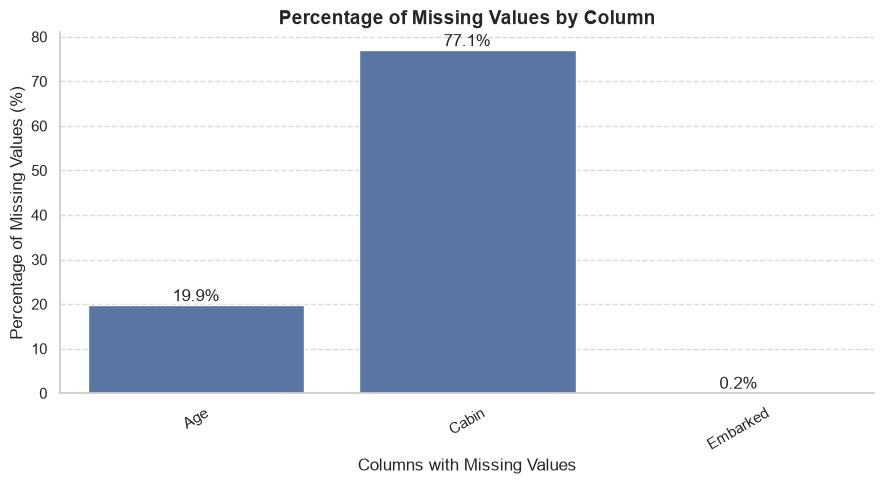

In [36]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    x=missing_summary[missing_summary.missing_count > 0].index,
    y='missing_pct',
    data=missing_summary[missing_summary.missing_count > 0],
    ax=ax
) 

ax.set_title("Percentage of Missing Values by Column",
             fontsize=14, fontweight='bold') 
ax.set_xlabel("Columns with Missing Values", fontsize=12)
ax.set_ylabel("Percentage of Missing Values (%)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

#### Checking number of duplicated rows

In [37]:
print(f"Number of duplicated rows: {df.duplicated().sum()}")

Number of duplicated rows: 0


**Observations:**
- `Cabin` is missing 687 values which is approximately about 77% of records — too sparse to impute reliably; we'll engineer a binary indicator instead.
- `Age` is missing 177 values which is approximately about 20% of records — enough to impute rather than drop.
- `Embarked` has only 2 missing values which is approximately about 0.2% — safe to impute with the mode.
- No duplicate rows found.


## **3. Data Cleaning**

In [38]:
df_clean = df.copy()

# Embarked: impute with mode (only 2 missing) 
mode_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(mode_embarked)

# Cabin: too sparse to impute; create indicator, then drop 
df_clean['HasCabin'] = df_clean['Cabin'].notnull().astype(int)
df_clean = df_clean.drop(columns=['Cabin'])

# Age: impute using median Age grouped by Title (see feature engineering below) 
# Placeholder here; final imputation happens after Title is extracted.

print("Nulls remaining before Age imputation:")
df_clean.isnull().sum()


Nulls remaining before Age imputation:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
HasCabin         0
dtype: int64

**Cleaning decisions:**
- **Embarked** → filled with the mode(s), since only 2 rows are affected.
- **Cabin** → converted to a binary `HasCabin` flag (having a recorded cabin correlates with class/fare) rather than imputing an unobservable value; original column dropped.
- **Age** → deferred until after Title extraction, so missing ages can be imputed using a more informative group (Title) rather than a single global median.

##  4. Feature Engineering 

In [39]:
# Title extraction from Name 
df_clean['Title'] = df_clean['Name'].str.extract(r',\s*([^.]*)\.')

# Consolidate rare/alternate titles into standard buckets
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}
df_clean['Title'] = df_clean['Title'].replace(title_map)
df_clean['Title'].value_counts()

Title
Mr              517
Miss            185
Mrs             126
Master           40
Rare             22
the Countess      1
Name: count, dtype: int64

In [40]:
# Age imputation using median Age per Title
df_clean['Age'] = df_clean.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
# Fallback for any Title group with no known ages
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

print(f"Remaining Age nulls: {df_clean['Age'].isnull().sum()}")

Remaining Age nulls: 0


In [41]:
# Family-based features
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

# Binned features (useful for some models / EDA)
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[0, 12, 18, 35, 60, 100],
                                labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
df_clean['FareBin'] = pd.qcut(df_clean['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

# Drop columns not useful for modeling in raw form 
df_model = df_clean.drop(columns=['PassengerId', 'Name', 'Ticket'])

df_model.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Title,FamilySize,IsAlone,AgeGroup,FareBin
0,0,3,male,22.0,1,0,7.2500,S,0,Mr,2,0,Young Adult,Low
1,1,1,female,38.0,1,0,71.2833,C,1,Mrs,2,0,Adult,Very High
2,1,3,female,26.0,0,0,7.9250,S,0,Miss,1,1,Young Adult,Medium
3,1,1,female,35.0,1,0,53.1000,S,1,Mrs,2,0,Young Adult,Very High
4,0,3,male,35.0,0,0,8.0500,S,0,Mr,1,1,Young Adult,Medium


**Engineered features:**
- `Title` — extracted from `Name`; captures social status/age/gender signal more precisely than raw name text.
- `HasCabin` — binary indicator for cabin data availability (proxy for class/fare tier).
- `FamilySize` / `IsAlone` — combine `SibSp` and `Parch` into a more directly interpretable measure of travel group size.
- `AgeGroup`, `FareBin` — binned versions of continuous variables, useful for EDA and for models that benefit from categorical splits.
- Dropped `PassengerId`, `Name`, `Ticket` as raw modeling inputs (identifiers / high-cardinality text with limited direct signal beyond what's now captured in `Title`).


## 5. Exploratory Data Analysis

### 5.1 Target Variable is "Survival Rate"

Overall survival rate: 38.4%


C:\Users\Student\AppData\Local\Temp\ipykernel_300\1949422728.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Died (0)', 'Survived (1)'], rotation=0)


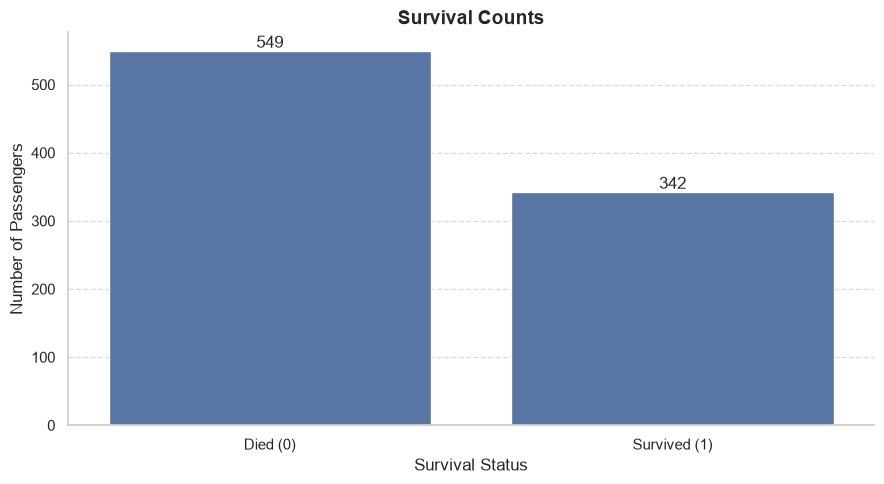

In [43]:
# Calculate and print survival rate
survival_rate = df_model['Survived'].mean()
print(f"Overall survival rate: {survival_rate:.1%}")

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(
    x='Survived', 
    data=df_model, 
    ax=ax
)

# Styling the titles and labels to match perfectly
ax.set_title("Survival Counts", fontsize=14, fontweight='bold') 
ax.set_xlabel("Survival Status", fontsize=12)
ax.set_ylabel("Number of Passengers", fontsize=12)

ax.set_xticklabels(['Died (0)', 'Survived (1)'], rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()


### 5.2 Distributions of Key Numeric Variables

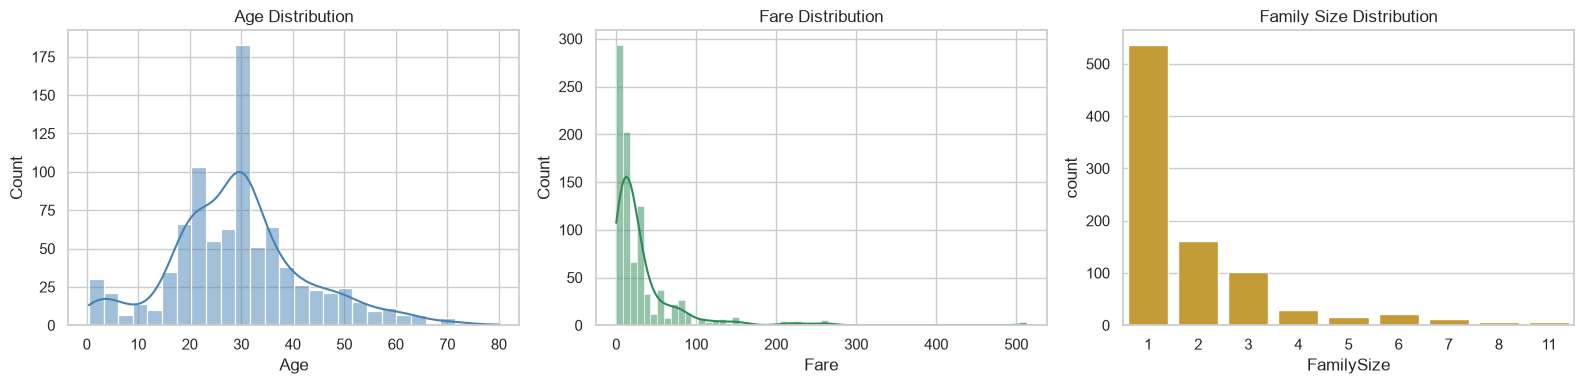

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_model['Age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df_model['Fare'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Fare Distribution')

sns.countplot(x='FamilySize', data=df_model, ax=axes[2], color='goldenrod')
axes[2].set_title('Family Size Distribution')

plt.tight_layout()
plt.show()

**Observations:**
- `Age` is roughly bell-shaped with a concentration in the 20–40 range and a long right tail.
- `Fare` is heavily right-skewed with a small number of very high-fare outliers — a log transform is likely beneficial for linear models.
- Most passengers traveled alone or with a small family (1–4 members); very large family sizes are rare.


### 5.3 Survival by Categorical Variables

C:\Users\Student\AppData\Local\Temp\ipykernel_300\1992376358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df_model, ax=axes[0,0], palette='Blues_d')
C:\Users\Student\AppData\Local\Temp\ipykernel_300\1992376358.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df_model, ax=axes[0,1], palette='Reds_d')
C:\Users\Student\AppData\Local\Temp\ipykernel_300\1992376358.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=df_model, ax=axes[1,0], palett

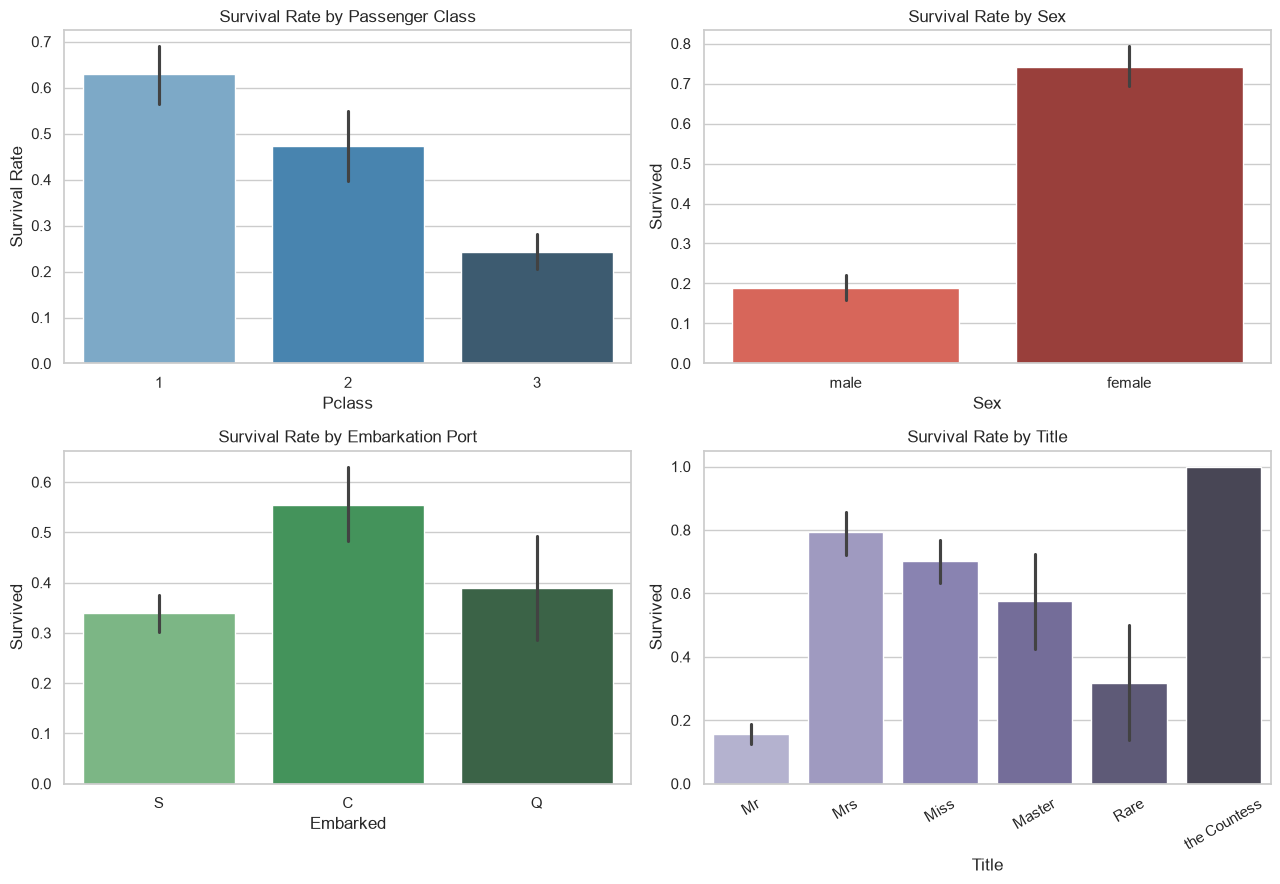

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.barplot(x='Pclass', y='Survived', data=df_model, ax=axes[0,0], palette='Blues_d')
axes[0,0].set_title('Survival Rate by Passenger Class')
axes[0,0].set_ylabel('Survival Rate')

sns.barplot(x='Sex', y='Survived', data=df_model, ax=axes[0,1], palette='Reds_d')
axes[0,1].set_title('Survival Rate by Sex')

sns.barplot(x='Embarked', y='Survived', data=df_model, ax=axes[1,0], palette='Greens_d')
axes[1,0].set_title('Survival Rate by Embarkation Port')

sns.barplot(x='Title', y='Survived', data=df_model, ax=axes[1,1], palette='Purples_d')
axes[1,1].set_title('Survival Rate by Title')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Observations:**
- **Sex** is the strongest single predictor — female passengers survived at a much higher rate than male passengers, consistent with "women and children first" evacuation priority.
- **Pclass** shows a clear gradient: first class passengers survived at notably higher rates than third class.
- **Embarked** shows some variation (Cherbourg passengers survived more often), though this is likely confounded with class/fare rather than a direct causal effect.
- **Title** closely tracks the Sex/age/class signal (e.g., "Mrs"/"Miss" survive more than "Mr") and may add predictive value beyond Sex alone by capturing marital status and age nuances.

### 5.4 Survival by Family Size, Age Group, and Fare Tier

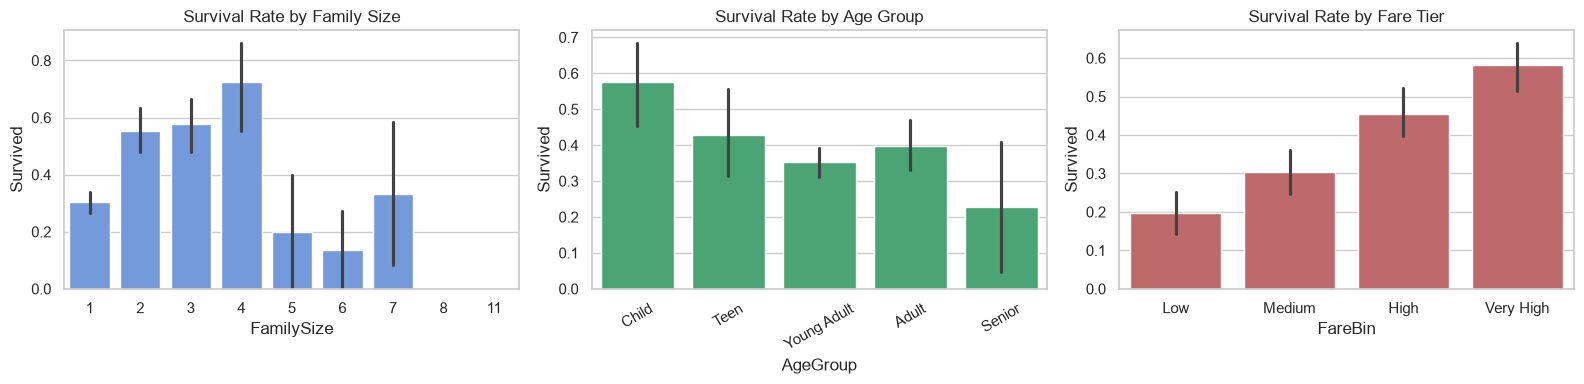

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(x='FamilySize', y='Survived', data=df_model, ax=axes[0], color='cornflowerblue')
axes[0].set_title('Survival Rate by Family Size')

sns.barplot(x='AgeGroup', y='Survived', data=df_model, ax=axes[1], color='mediumseagreen', order=['Child','Teen','Young Adult','Adult','Senior'])
axes[1].set_title('Survival Rate by Age Group')
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(x='FareBin', y='Survived', data=df_model, ax=axes[2], color='indianred', order=['Low','Medium','High','Very High'])
axes[2].set_title('Survival Rate by Fare Tier')

plt.tight_layout()
plt.show()

**Observations:**
- Survival peaks at moderate family sizes (2–4); solo travelers and very large families (6+) had lower survival rates — suggesting a non-linear relationship better captured by binning or an `IsAlone`/`FamilySize` combination than by `FamilySize` alone.
- Children show elevated survival, consistent with evacuation priority.
- Higher fare tiers correspond to higher survival, reinforcing the class/fare/survival relationship.


### 5.5 Numeric Relationships & Correlation

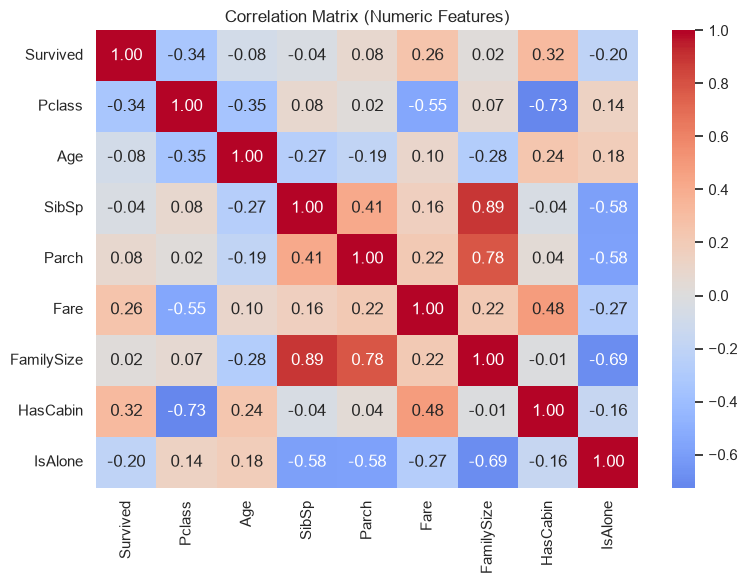

In [47]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'HasCabin', 'IsAlone']
corr = df_model[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()


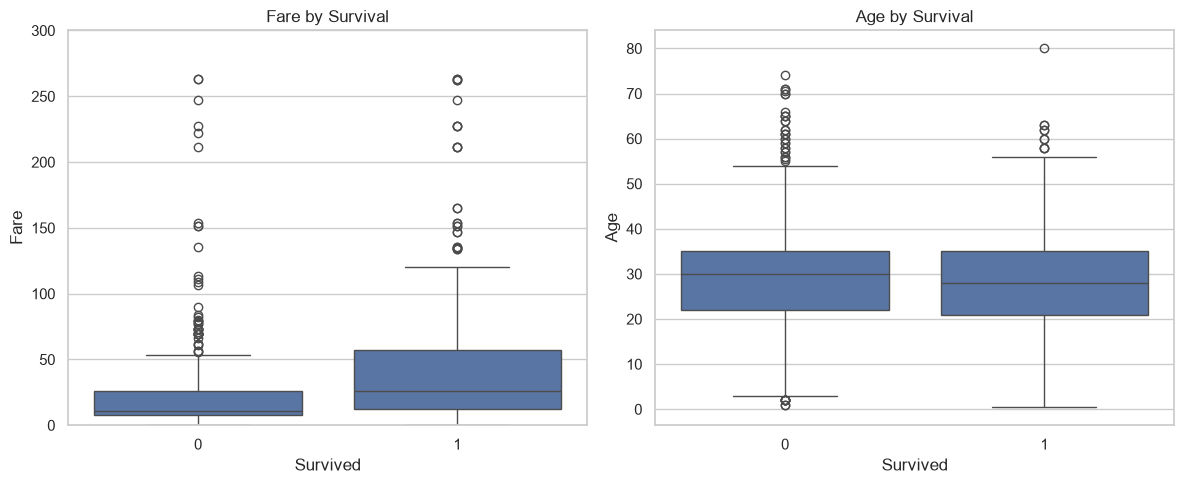

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='Survived', y='Fare', data=df_model, ax=axes[0])
axes[0].set_title('Fare by Survival')
axes[0].set_ylim(0, 300)

sns.boxplot(x='Survived', y='Age', data=df_model, ax=axes[1])
axes[1].set_title('Age by Survival')

plt.tight_layout()
plt.show()

**Observations:**
- `Pclass` and `Fare` are strongly (negatively/positively) correlated with `Survived`, as expected given the class-based evacuation pattern.
- `HasCabin` correlates positively with survival, mostly because cabin records are far more common among 1st class passengers.
- `Age` shows only a weak linear correlation with survival overall, but the earlier age-group breakdown shows the relationship is non-linear (children benefit, general adult range doesn't vary much) — a linear model may miss this without binning or a non-linear feature.
- No pair of numeric features shows extreme multicollinearity that would require immediate removal, though `Fare` and `Pclass` are moderately correlated.


## 6. Key Insights & Modeling Recommendations

**Strongest predictors identified:**
1. **Sex** — the single strongest signal; must be included and properly encoded.
2. **Pclass / Fare** — capture socioeconomic tier and cabin location; strongly related to evacuation priority. Consider using both, or a combined tier feature, but watch for mild collinearity between them.
3. **Title** — adds nuance beyond Sex (e.g., distinguishes married/unmarried women, flags rare/elite titles) and is a good candidate categorical feature.
4. **FamilySize / IsAlone** — the non-linear "sweet spot" (2–4 members survive best) suggests binning FamilySize or including both the raw count and the `IsAlone` flag rather than relying on a single linear term.
5. **Age** — best used after imputation by Title-group median; the `AgeGroup` binned feature may capture the (mostly non-linear) child-survival effect better than raw age for linear/logistic models, though tree-based models can use raw Age directly.
6. **HasCabin** — a useful engineered proxy for missing cabin data, but likely redundant with Fare/Pclass — worth checking feature importance/multicollinearity during modeling rather than assuming it's independent signal.

**Data quality considerations carried into modeling:**
- `Cabin` original column was too sparse (~77% missing) to impute directly — replaced with a binary indicator.
- `Age` missingness (~20%) was addressed via Title-grouped median imputation, more informative than a single global median.
- `Fare` is right-skewed — consider a log transform for models sensitive to feature scale/distribution (e.g., linear/logistic regression), though tree-based models (Random Forest, Gradient Boosting) are robust to this without transformation.
- `Embarked` had negligible missingness and was imputed with the mode.
- No duplicate records were found, so no deduplication was necessary.

**Suggested next steps for modeling:**
- Encode categorical variables (`Sex`, `Embarked`, `Title`, `AgeGroup`, `FareBin`) via one-hot or ordinal encoding depending on the chosen algorithm.
- Consider dropping either `HasCabin` or a portion of the class/fare features if multicollinearity checks (e.g., VIF) flag redundancy.
- Start with a tree-based baseline (Random Forest / Gradient Boosting) given the non-linear relationships observed (e.g., FamilySize, AgeGroup), then compare against a regularized logistic regression baseline for interpretability.
- Use stratified train/validation splits on `Survived` to preserve the ~38% overall survival rate across folds.


In [49]:
# Final cleaned & feature-engineered dataset, ready for modeling
df_model.to_csv(r'C:\Users\Student\Downloads\archive\Titanic_Dataset.csv', index=False)
print(f"Saved cleaned dataset: {df_model.shape[0]} rows, {df_model.shape[1]} columns")
df_model.head()

Saved cleaned dataset: 891 rows, 14 columns


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Title,FamilySize,IsAlone,AgeGroup,FareBin
0,0,3,male,22.0,1,0,7.2500,S,0,Mr,2,0,Young Adult,Low
1,1,1,female,38.0,1,0,71.2833,C,1,Mrs,2,0,Adult,Very High
2,1,3,female,26.0,0,0,7.9250,S,0,Miss,1,1,Young Adult,Medium
3,1,1,female,35.0,1,0,53.1000,S,1,Mrs,2,0,Young Adult,Very High
4,0,3,male,35.0,0,0,8.0500,S,0,Mr,1,1,Young Adult,Medium
